### Imports libraries

In [2]:
from util import get_data_merged, get_data_frames, alert_end

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import pickle

from scipy import stats
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.decomposition import PCA
from joblib import dump, load

### Data processing

In [18]:
data_log, data_dash = get_data_frames()
features, labels = get_data_merged(data_log, data_dash)
features = features.drop(columns=["timestamp"])
features

,ingress_global_timestamp3,egress_global_timestamp3,enq_timestamp3,enq_qdepth3,deq_timedelta3,deq_qdepth3,ingress_global_timestamp2,egress_global_timestamp2,enq_timestamp2,enq_qdepth2,deq_timedelta2,deq_qdepth2,ingress_global_timestamp1,egress_global_timestamp1,enq_timestamp1,enq_qdepth1,deq_timedelta1,deq_qdepth1
0,39094865473,39094865660,440159961,0,39,0,39169118133,39169118318,514412620,0,36,0,39245046271,39245046453,590340761,0,30,0
1,39094947171,39094947281,440241591,0,29,0,39169199652,39169199877,514494180,0,35,0,39245127761,39245127953,590422260,0,32,0
2,39095064755,39095064937,440359239,0,36,0,39169317436,39169317605,514611910,0,34,0,39245245663,39245245851,590540158,0,31,0
3,39095165462,39095165651,440459953,0,37,0,39169418150,39169418331,514712634,0,36,0,39245346337,39245346527,590640834,0,31,0
4,39095283945,39095284124,440578433,0,29,0,39169536646,39169536827,514831136,0,29,0,39245464819,39245465008,590759307,0,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575701,71351974315,71351974739,2632497912,0,93,0,71426244529,71426245631,2706768873,1,23,2,71502168488,71502169126,2782692280,3,111,6
575702,71352024850,71352024981,2632548203,0,44,0,71426294611,71426295052,2706818043,2,274,0,71502220323,71502221057,2782744295,0,27,0
575703,71352072048,71352072356,2632595587,0,34,0,71426342111,71426342685,2706865830,0,120,0,71502265166,71502265445,2782788687,0,24,0
575704,71352120262,71352120360,2632643585,0,41,0,71426388113,71426388289,2706911479,0,76,0,71502315146,71502315343,2782838588,0,20,0


### Models

In [5]:
def normalized_mae(true_values, predicted_values):
    mae_value = mean_absolute_error(true_values, predicted_values)
    nmae_value = mae_value / np.mean(true_values)
    return nmae_value

In [6]:
def train_random_forest_randomsearch(features: pd.DataFrame, labels: pd.Series):
    X_train, X_val, y_train, y_val = train_test_split(
        features,
        np.ravel(labels),
        test_size=0.20,
        random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    rf_model = RandomForestRegressor(random_state=42, n_jobs=2)

    nmae_scorer = make_scorer(normalized_mae, greater_is_better=False)

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    param_dist = {
        'n_estimators': [50, 100, 150],
        'max_features': ['log2', 'sqrt'],
        'max_depth': [20, 30, 50, 60, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'bootstrap': [True, False]
    }

    random_search = RandomizedSearchCV(
        estimator=rf_model,
        param_distributions=param_dist,
        scoring=nmae_scorer,
        cv=kfold,
        n_iter=20, 
        verbose=3,
        n_jobs=1,
        random_state=42
    )

    random_search.fit(X_train_scaled, y_train)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    y_pred = best_model.predict(X_val_scaled)
    mae_value = mean_absolute_error(y_val, y_pred)
    nmae_value = normalized_mae(y_val, y_pred)

    return mae_value, nmae_value, best_model, best_params, X_val_scaled, y_val

In [7]:
def train_xgboost_randomsearch(features: pd.DataFrame, labels: pd.Series):
    X_train, X_val, y_train, y_val = train_test_split(
        features,
        np.ravel(labels),
        test_size=0.20,
        random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=2)

    nmae_scorer = make_scorer(normalized_mae, greater_is_better=False)

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    param_dist = {
        'n_estimators': [150, 300, 450],
        'max_depth': [10, 15, 25],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0],
    }

    random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_dist,
        scoring=nmae_scorer,
        cv=kfold,
        n_iter=20, 
        verbose=3,
        n_jobs=1,
        random_state=42
    )

    random_search.fit(X_train_scaled, y_train)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    y_pred = best_model.predict(X_val_scaled)
    mae_value = mean_absolute_error(y_val, y_pred)
    nmae_value = normalized_mae(y_val, y_pred)

    return mae_value, nmae_value, best_model, best_params, X_val_scaled, y_val

In [24]:
def train_xgboost(features: pd.DataFrame, labels: pd.Series):
    X_train, X_val, y_train, y_val = train_test_split(
        features,
        np.ravel(labels),
        test_size=0.20,
        random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    xgb_model = xgb.XGBRegressor(
        random_state=42,
        n_jobs=-1,
        n_estimators=300,    
        max_depth=15,
        learning_rate=0.01,
       
    )

    xgb_model.fit(X_train_scaled, y_train)

    y_pred = xgb_model.predict(X_val_scaled)
    mae_value = mean_absolute_error(y_val, y_pred)
    nmae_value = normalized_mae(y_val, y_pred)

    return mae_value, nmae_value, xgb_model, X_val_scaled, y_val


In [19]:
def train_random_forest_kfold(features: pd.DataFrame, labels: pd.Series):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae_values = []
    nmae_values = []
    models = []
    
    for train_index, val_index in kf.split(features):
        X_train, X_val = features.iloc[train_index], features.iloc[val_index]
        y_train, y_val = labels.iloc[train_index], labels.iloc[val_index]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        rf_model = RandomForestRegressor(
            random_state=42,
            n_estimators=100,
            max_features='sqrt',
            max_depth=64,
            min_samples_split=2,
            min_samples_leaf=1,
            bootstrap=True,
            verbose=3,
            n_jobs=2
        )

        rf_model.fit(X_train_scaled, y_train)

        y_pred = rf_model.predict(X_val_scaled)
        mae_value = mean_absolute_error(y_val, y_pred)
        nmae_value = normalized_mae(y_val, y_pred)

        mae_values.append(mae_value)
        nmae_values.append(nmae_value)
        models.append(rf_model)

    return np.mean(mae_values), np.mean(nmae_values), models[-1]

In [ ]:
def train_random_forest(features: pd.DataFrame, labels: pd.Series):
    X_train, X_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    rf_model = RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        max_features='sqrt',
        max_depth=64,
        min_samples_split=2,
        min_samples_leaf=1,
        bootstrap=True,
        verbose=3,
        n_jobs=2
    )

    rf_model.fit(X_train_scaled, y_train)

    y_pred = rf_model.predict(X_val_scaled)

    mae_value = mean_absolute_error(y_val, y_pred)
    nmae_value = normalized_mae(y_val, y_pred)

    return mae_value, nmae_value, rf_model


### Train models

In [ ]:
rf_mae, rf_nmae, rf_best_model, rf_best_params, rf_X_val_scaled, rf_y_val = train_random_forest_randomsearch(features, labels)
rf_y_pred = best_model.predict(rf_X_val_scaled)
visualize_results(rf_y_val, rf_y_pred, rf_best_params, rf_features.columns)
alert_end()

In [ ]:
xgb_mae, xgb_nmae, xgb_best_model, xgb_best_params, xgb_X_val_scaled, xgb_y_val = train_xgboost_randomsearch(features, labels)
xgb_y_pred = best_model.predict(xgb_X_val_scaled)
visualize_results(xgb_y_val, xgb_y_pred, xgb_best_params, features.columns)
alert_end()

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100


[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:  1.4min


building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73

[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    0.4s


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100


...

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100


[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:  1.4min


building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73

[Parallel(n_jobs=1)]: Done  31 tasks      | elapsed:    0.4s


5.798425968583511%


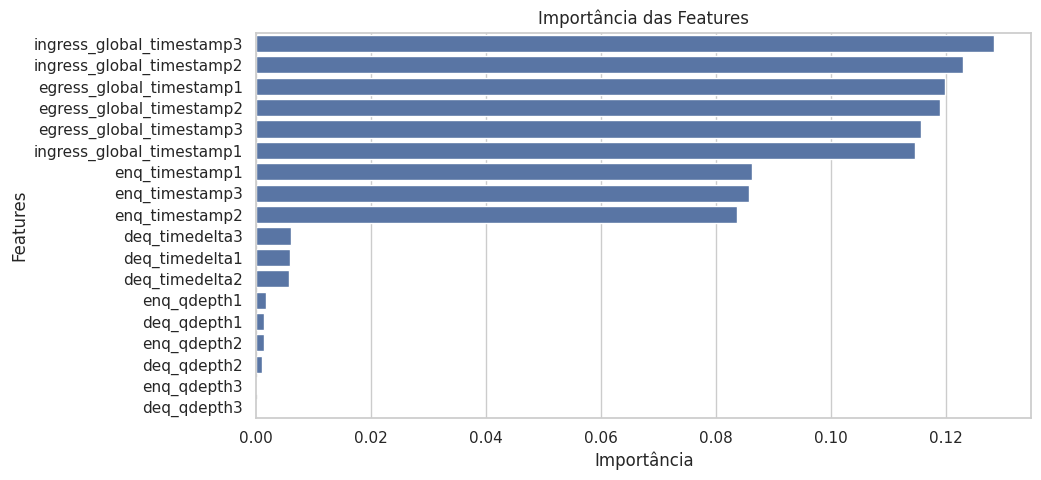

In [25]:
xgb_mae, xgb_nmae, xgb_best_model = train_random_forest(features, labels)
print(f"{xgb_nmae*100}%")
visualize_results(xgb_best_model.feature_importances_, features.columns)
alert_end()

In [ ]:
rf_mae, rf_nmae, rf_best_model = train_random_forest(features, labels)
print(f"{rf_nmae*100}%")
visualize_results(rf_best_model.feature_importances_, features.columns)
alert_end()

In [ ]:
rf_mae, rf_nmae, rf_best_model, rf_X_val_scaled, rf_y_val = train_random_forest(features, labels)
print(f"{rf_nmae*100}%")
rf_y_pred = rf_best_model.predict(rf_X_val_scaled)
visualize_results(rf_y_val, rf_y_pred, rf_best_model.feature_importances_, features.columns)
alert_end()

### Visualize

In [10]:
def visualize_results_random_search(feature_importances, feature_names):

    feature_importances_df = pd.DataFrame({
        'Features': feature_names,
        'Importância': feature_importances
    }).sort_values(by='Importância', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importância', y='Features', data=feature_importances_df)
    plt.title('Importância das Features')
    plt.xlabel('Importância')
    plt.ylabel('Features')
    plt.show()

In [20]:
def visualize_results(feature_importances, feature_names):

    feature_importances_df = pd.DataFrame({
        'Features': feature_names,
        'Importância': feature_importances
    }).sort_values(by='Importância', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importância', y='Features', data=feature_importances_df)
    plt.title('Importância das Features')
    plt.xlabel('Importância')
    plt.ylabel('Features')
    plt.show()